## HSBC Time Series Analysis

## Introduction
This notebook performs a time series analysis of HSBC stock data.
The analysis begins with exploratory data analysis, followed by statistical modeling and forecasting with a focus on banking-sector behavior

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

plt.style.use("seaborn-v0_8")

In [3]:
hsbc = yf.download("HSBC", start="2020-01-01", end="2025-01-01")
hsbc.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,HSBC,HSBC,HSBC,HSBC,HSBC
Date,,,,,
2020-01-02,27.528950,27.528950,27.326173,27.368126,2046900
2020-01-03,27.102419,27.221291,26.997535,27.011520,1694800
2020-01-06,27.011522,27.025507,26.766788,26.766788,1807500
2020-01-07,26.808737,26.843698,26.724829,26.759790,2638800
2020-01-08,26.745806,26.836707,26.501074,26.501074,2299600


In [5]:
hsbc.columns

MultiIndex([( 'Close', 'HSBC'),
            (  'High', 'HSBC'),
            (   'Low', 'HSBC'),
            (  'Open', 'HSBC'),
            ('Volume', 'HSBC')],
           names=['Price', 'Ticker'])

In [6]:
hsbc_price = hsbc["Close"]["HSBC"]
hsbc_price.head()

Date
2020-01-02    27.528950
2020-01-03    27.102419
2020-01-06    27.011522
2020-01-07    26.808737
2020-01-08    26.745806
Name: HSBC, dtype: float64

Adjusted Close prices are used as they account for dividends and stock splits, making them more suitable for financial and banking analysis.

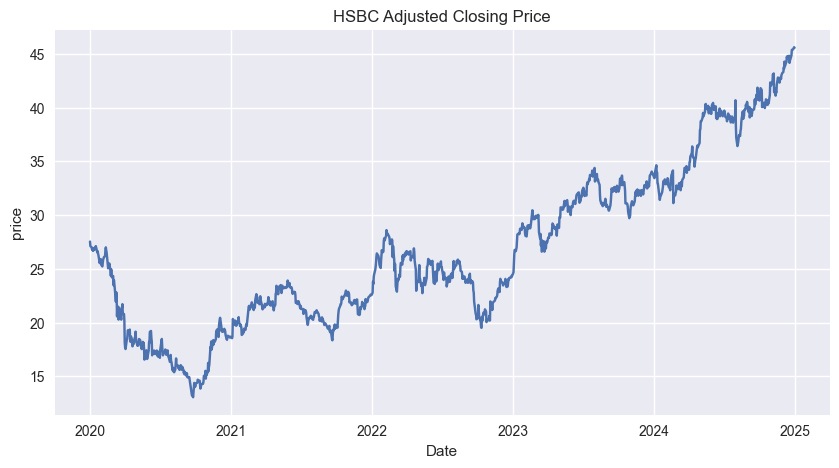

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(hsbc_price)
plt.title("HSBC Adjusted Closing Price")
plt.xlabel("Date")
plt.ylabel("price")
plt.show()

### Observations
- HSBC prices show long-term stability consistent with a  large banking institution.
- Significant volatility is visible during the COVID-19 period.
- Price movements reflects sensitivity to macroeconomic conditions.

In [8]:
hsbc_returns = hsbc_price.pct_change().dropna()
hsbc_returns.head()

Date
2020-01-03   -0.015494
2020-01-06   -0.003354
2020-01-07   -0.007507
2020-01-08   -0.002347
2020-01-09    0.006536
Name: HSBC, dtype: float64

Daily returns are used instead of prices because return series are more suitable for statistical modeling and financial risk analysis.

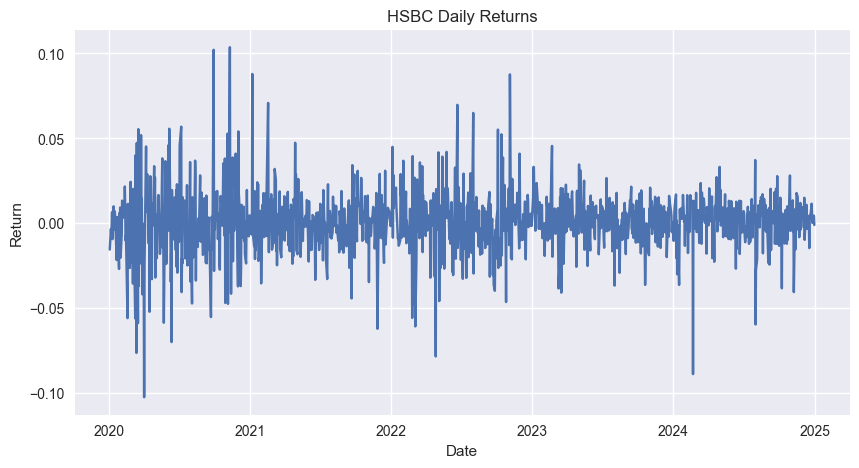

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(hsbc_returns)
plt.title("HSBC Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.show()

### Observations
-Returns fluctuate around a mean close to zero.
-Volatility clustering is visible, especially during crisis periods.
Large spikes indicate periods of financial stress.